# Custom parity-check matrix `H` + Stim syndrome generation

This notebook lets you:
1. Define a parity-check matrix `H` manually.
2. Build a Stim circuit that measures each check (syndrome bits).
3. Collect `(syndrome, data_measurement)` samples.
4. Plug in your own decoder algorithm and evaluate it.

In [81]:
import numpy as np
import stim
import matplotlib.pyplot as plt

In [104]:
# --- 1) Define your custom H manually (rows=checks, cols=data qubits) ---
H = np.array(
    [
        [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
        [1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0],
        [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    ],
    dtype=np.uint8,
)

assert H.ndim == 2
assert set(np.unique(H)).issubset({0, 1})

num_checks, num_data = H.shape
print(f"H shape: checks={num_checks}, data={num_data}")
print(H)

H shape: checks=5, data=12
[[1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1]
 [1 1 0 0 1 1 0 0 1 1 0 0]
 [1 0 1 0 1 0 1 0 1 0 1 0]]


In [ ]:
def build_syndrome_circuit_from_H(H: np.ndarray, p_data: float = 0.02, p_meas: float = 0.0) -> stim.Circuit:
    """
    Build one-round X-noise memory circuit with Z-check syndrome extraction from H.

    - Data qubits: 0 .. n-1
    - Ancilla/check qubits: n .. n+m-1 (one per row of H)
    - Syndrome bits are ancilla measurements (and matching DETECTOR bits).
    """
    H = (H % 2).astype(np.uint8)
    m, n = H.shape

    data = list(range(n))
    anc = list(range(n, n + m))

    circuit = stim.Circuit()
    circuit.append("R", data + anc)
    circuit.append("X_ERROR", data, float(p_data))

    for i in range(m):
        a = anc[i]
        support = [j for j, bit in enumerate(H[i]) if bit]
        circuit.append("H", [a])
        for q in support:
            circuit.append("CZ", [a, q])
        circuit.append("H", [a])
        if p_meas > 0:
            circuit.append("X_ERROR", [a], float(p_meas))
        circuit.append("M", [a])
        circuit.append("DETECTOR", [stim.target_rec(-1)])

    circuit.append("M", data)
    return circuit


def sample_syndrome_dataset(circuit: stim.Circuit, H: np.ndarray, shots: int = 1000):
    """
    Returns:
      syndromes: shape (shots, m)
      data_meas: shape (shots, n)
    Measurement order in this circuit is [all ancilla M, then all data M].
    """
    m, n = H.shape
    sampler = circuit.compile_sampler()
    meas = sampler.sample(shots=shots).astype(np.uint8)

    syndromes = meas[:, :m]
    data_meas = meas[:, m:m+n]
    return syndromes, data_meas

In [ ]:
def decode_batch(syndromes: np.ndarray, H: np.ndarray, decode_one_fn) -> np.ndarray:
    est = [decode_one_fn(s.astype(np.uint8), H) for s in syndromes]
    return np.array(est, dtype=np.uint8)


def evaluate_decoder(H: np.ndarray, syndromes: np.ndarray, data_meas: np.ndarray, decode_one_fn):
    """
    For this simple one-round X-noise model, data Z-basis measurements equal the
    sampled X-error pattern on data qubits. We compare e_hat directly to data_meas.
    """
    e_hat = decode_batch(syndromes, H, decode_one_fn)
    per_shot_fail = np.any((e_hat ^ data_meas) != 0, axis=1)
    block_error_rate = float(np.mean(per_shot_fail))
    return {
        "shots": int(len(syndromes)),
        "fails": int(np.sum(per_shot_fail)),
        "block_error_rate": block_error_rate,
    }

In [ ]:
# --- 2) Build circuit and inspect ---
p_data = 0.005
p_meas = 0.0
shots = 5000

circuit = build_syndrome_circuit_from_H(H, p_data=p_data, p_meas=p_meas)

# circuit.diagram("timeline-svg")

In [ ]:
# --- 3) Generate syndrome/data dataset ---
syndromes, data_meas = sample_syndrome_dataset(circuit, H, shots=shots)

print("syndromes shape:", syndromes.shape)
print("data_meas shape:", data_meas.shape)
print("first 5 syndrome rows:\n", syndromes[:5])
print("first 5 data rows:\n", data_meas[:5])

# sanity: check that H @ data_meas^T matches syndrome for p_meas=0
pred_syn = (data_meas @ H.T) % 2
consistency = np.mean(np.all(pred_syn == syndromes, axis=1))
print(f"Consistency P(H*e = s): {consistency:.4f}")

In [ ]:
def custom_decode_one(s: np.ndarray, H: np.ndarray) -> np.ndarray:
    """
    Replace this with your own decoder.
    Input:
      s: syndrome bit-vector of shape (m,)
      H: parity-check matrix shape (m, n)
    Output:
      e_hat: estimated data error vector shape (n,), binary
    """

    indices = []

    key = (H.shape, H.tobytes())
    if not hasattr(custom_decode_one, "_cache"):
        custom_decode_one._cache = {}

    if key not in custom_decode_one._cache:
        m, n_lut = H.shape
        lut = {}

        for mask in range(1 << n_lut):
            e = np.fromiter(((mask >> j) & 1 for j in range(n_lut)), dtype=np.uint8, count=n_lut)
            syn = tuple(((H @ e) & 1).tolist())
            w = mask.bit_count()

            if syn not in lut or w < lut[syn][0]:
                idxs = [j for j in range(n_lut) if (mask >> j) & 1]
                lut[syn] = (w, idxs)

        custom_decode_one._cache[key] = {syn: idxs for syn, (_, idxs) in lut.items()}

    s_key = tuple((s.astype(np.uint8) & 1).tolist())
    indices = custom_decode_one._cache[key].get(s_key, [])

    n = H.shape[1]
    e_hat = np.zeros(n, dtype=np.uint8)
    for idx in indices:
        e_hat[idx] = 1
    return e_hat

In [ ]:
# --- 2) Build circuit and inspect ---
err_rate_array = []
p_data_values = np.array([0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001], dtype=float)
for p_data in p_data_values:
    p_meas = 0.0
    shots = 1_000_000

    circuit = build_syndrome_circuit_from_H(H, p_data=p_data, p_meas=p_meas)

    # circuit.diagram("timeline-svg")
    syndromes, data_meas = sample_syndrome_dataset(circuit, H, shots=shots)

    # --- 4) Run your custom decoder ---
    metrics = evaluate_decoder(H, syndromes, data_meas, custom_decode_one)
    err_rates = metrics["block_error_rate"]
    err_rate_array.append(err_rates)
    print("Custom decoder metrics:", metrics)

plt.figure(figsize=(6, 4))
plt.loglog(p_data_values, err_rate_array, marker="o")
plt.loglog(p_data_values, p_data_values, marker="*", linestyle="--")
plt.xlabel("p_data")
plt.ylabel("Block error rate")
plt.title("Decoder error rate vs p_data")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# H2

In [84]:
# Generalized construction: 4-bit blocks + 2 disambiguation rows
def make_H(n:int):
    n_cols = 4*n  # or set explicitly, e.g. n_cols = 12
    assert n_cols % 4 == 0, "Number of columns must be a multiple of 4."

    n_blocks = n_cols // 4

    # First rows: one row per block, with contiguous 1111 shifted by 4 each row
    top = np.kron(np.eye(n_blocks, dtype=np.uint8), np.ones((1, 4), dtype=np.uint8))

    # Last two rows: repeated patterns to distinguish the 4 positions in each block
    r1 = np.tile(np.array([1, 1, 0, 0], dtype=np.uint8), n_blocks)
    r2 = np.tile(np.array([1, 0, 1, 0], dtype=np.uint8), n_blocks)

    H_loc = np.vstack([top, r1, r2]).astype(np.uint8)
    return H_loc

print(make_H(4))

[[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
 [1 1 0 0 1 1 0 0 1 1 0 0 1 1 0 0]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]]


In [150]:
n_values = list(range(0, 1000, 10))
num_ancillas = [n + 2 for n in n_values]
rates = [n*4/(n*4 + num_ancillas[i]) for i, n in enumerate(n_values)]
for i,n in enumerate(n_values):
    print(f"n={n} ; r={rates[i]}")

n=0 ; r=0.0
n=10 ; r=0.7692307692307693
n=20 ; r=0.7843137254901961
n=30 ; r=0.7894736842105263
n=40 ; r=0.7920792079207921
n=50 ; r=0.7936507936507936
n=60 ; r=0.7947019867549668
n=70 ; r=0.7954545454545454
n=80 ; r=0.7960199004975125
n=90 ; r=0.7964601769911505
n=100 ; r=0.796812749003984
n=110 ; r=0.7971014492753623
n=120 ; r=0.7973421926910299
n=130 ; r=0.7975460122699386
n=140 ; r=0.7977207977207977
n=150 ; r=0.7978723404255319
n=160 ; r=0.7980049875311721
n=170 ; r=0.7981220657276995
n=180 ; r=0.7982261640798226
n=190 ; r=0.7983193277310925
n=200 ; r=0.7984031936127745
n=210 ; r=0.7984790874524715
n=220 ; r=0.7985480943738656
n=230 ; r=0.7986111111111112
n=240 ; r=0.7986688851913477
n=250 ; r=0.7987220447284346
n=260 ; r=0.7987711213517665
n=270 ; r=0.7988165680473372
n=280 ; r=0.7988587731811697
n=290 ; r=0.7988980716253443
n=300 ; r=0.7989347536617842
n=310 ; r=0.7989690721649485
n=320 ; r=0.7990012484394506
n=330 ; r=0.7990314769975787
n=340 ; r=0.799059929494712
n=350 ; r=0.7

Starting n = 3 ; rate = 0.7058823529411765
Custom decoder metrics: {'shots': 5000000, 'fails': 477770, 'block_error_rate': 0.095554}
Custom decoder metrics: {'shots': 5000000, 'fails': 23995, 'block_error_rate': 0.004799}
Custom decoder metrics: {'shots': 5000000, 'fails': 6266, 'block_error_rate': 0.0012532}
Custom decoder metrics: {'shots': 5000000, 'fails': 241, 'block_error_rate': 4.82e-05}
Custom decoder metrics: {'shots': 5000000, 'fails': 67, 'block_error_rate': 1.34e-05}
Custom decoder metrics: {'shots': 5000000, 'fails': 2, 'block_error_rate': 4e-07}
Starting n = 4 ; rate = 0.7272727272727273
Custom decoder metrics: {'shots': 5000000, 'fails': 775876, 'block_error_rate': 0.1551752}
Custom decoder metrics: {'shots': 5000000, 'fails': 43058, 'block_error_rate': 0.0086116}
Custom decoder metrics: {'shots': 5000000, 'fails': 11300, 'block_error_rate': 0.00226}
Custom decoder metrics: {'shots': 5000000, 'fails': 488, 'block_error_rate': 9.76e-05}
Custom decoder metrics: {'shots': 5

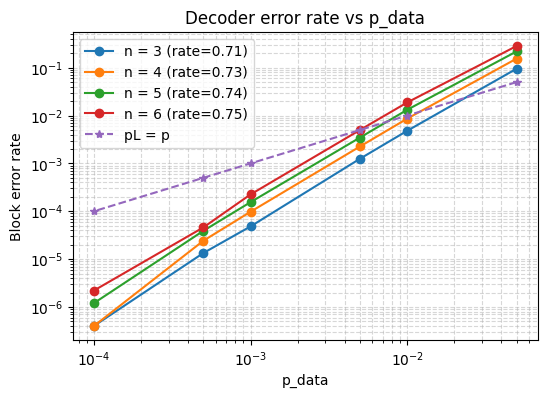

In [80]:
# --- 2) Build circuit and inspect ---
p_meas = 0.0
shots = 5_000_000

n_values = [3,4,5,6]
num_ancillas = [n + 2 for n in n_values]
rates = [n*4/(n*4 + num_ancillas[i]) for i, n in enumerate(n_values)]
p_data_values = np.array([0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001], dtype=float)
err_rate_over_n = []
for i,n in enumerate(n_values):
    H_2 = make_H(n)
    print("Starting n =", n, "; rate =", rates[i])
    err_rate_array = []
    for p_data in p_data_values:
        circuit = build_syndrome_circuit_from_H(H_2, p_data=p_data, p_meas=p_meas)
        syndromes, data_meas = sample_syndrome_dataset(circuit, H_2, shots=shots)

        # --- 4) Run your custom decoder ---
        metrics = evaluate_decoder(H_2, syndromes, data_meas, custom_decode_one)
        err_rates = metrics["block_error_rate"]
        err_rate_array.append(err_rates)
        print("Custom decoder metrics:", metrics)
    err_rate_over_n.append(err_rate_array)

plt.figure(figsize=(6, 4))
for idx, err_rates in enumerate(err_rate_over_n):
    plt.loglog(p_data_values, err_rates, marker="o", label=f"n = {n_values[idx]} (rate={rates[idx]:.2f})")
plt.loglog(p_data_values, p_data_values, marker="*", linestyle="--", label="pL = p")
plt.xlabel("p_data")
plt.ylabel("Block error rate")
plt.title("Decoder error rate vs p_data")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## Codespace and logical operators for this H

### 1) What code is defined by this notebook right now?
You currently define only one binary check matrix `H` and measure it as Z-type stabilizer checks.

- Data qubits: `n = 12`
- Check rows: `m = 5`
- Stabilizers: one Z-check per row of `H`

Each row $h_i$ defines:
- $S_i$ = product of $Z_j$ over all columns j where $h_i[j] = 1$

So the codespace is the set of states stabilized by all checks:
- $S_i \ket\psi =\ket\psi$ for every check row `i`

Equivalent computational-basis view:
- basis states $\ket x$ are allowed if `H x = 0 (mod 2)`
- so codespace corresponds to the classical kernel/nullspace of `H`

---

### 2) How many encoded qubits does this imply?
For this Z-check-only model, encoded qubits are:
- `k = n - rank(H)`

For your displayed `H` (typically rank 5):
- `k = 12 - 5 = 7`

This means your current construction is good for X-error detection/correction experiments, but it is not yet a full symmetric quantum code (no X stabilizers are defined).

---

### 3) Logical operators from this H
Because checks are Z-type:

- Logical X candidates are binary vectors `xL` such that:
  - `H xL = 0 (mod 2)`
  - (they commute with all Z checks)

- Z stabilizers are generated by row combinations of `H`.

To get a canonical logical basis:
1. Compute a basis of `null(H)` over GF(2) -> gives X-type logical candidates.
2. Compute rowspace of `H` -> gives trivial Z operators (stabilizers).
3. Pick `k` independent X logicals.
4. Build `k` Z logicals paired with them so each pair anticommutes and different pairs commute.

Pairing rule over GF(2):
- `xL_i dot zL_j = 1` if `i == j`, else `0`.

---

In [105]:
# Build logical-operator bases dynamically from H = make_H(n)

def gf2_rref(A: np.ndarray):
    M = (A.copy() & 1).astype(np.uint8)
    m, n = M.shape
    pivots = []
    r = 0
    for c in range(n):
        pivot = None
        for rr in range(r, m):
            if M[rr, c]:
                pivot = rr
                break
        if pivot is None:
            continue
        if pivot != r:
            M[[r, pivot]] = M[[pivot, r]]
        for rr in range(m):
            if rr != r and M[rr, c]:
                M[rr] ^= M[r]
        pivots.append(c)
        r += 1
        if r == m:
            break
    return M, pivots


def gf2_rank(A: np.ndarray) -> int:
    _, piv = gf2_rref(A)
    return len(piv)


def gf2_nullspace_basis(A: np.ndarray) -> np.ndarray:
    R, piv = gf2_rref(A)
    m, n = R.shape
    free_cols = [c for c in range(n) if c not in piv]
    if not free_cols:
        return np.zeros((0, n), dtype=np.uint8)

    basis = []
    for f in free_cols:
        v = np.zeros(n, dtype=np.uint8)
        v[f] = 1
        for row, pc in enumerate(piv):
            if R[row, f]:
                v[pc] = 1
        basis.append(v)
    return np.array(basis, dtype=np.uint8)


def gf2_rowspace_basis(A: np.ndarray) -> np.ndarray:
    R, _ = gf2_rref(A)
    nonzero = [row for row in R if np.any(row)]
    if not nonzero:
        return np.zeros((0, A.shape[1]), dtype=np.uint8)
    return np.array(nonzero, dtype=np.uint8)


def gf2_solve_one(A: np.ndarray, b: np.ndarray):
    """Solve A x = b over GF(2). Returns one solution (or None if inconsistent)."""
    A = (A.copy() & 1).astype(np.uint8)
    b = (b.copy() & 1).astype(np.uint8)
    m, n = A.shape

    Aug = np.hstack([A, b.reshape(-1, 1)])
    r = 0
    pivots = []

    for c in range(n):
        pivot = None
        for rr in range(r, m):
            if Aug[rr, c]:
                pivot = rr
                break
        if pivot is None:
            continue
        if pivot != r:
            Aug[[r, pivot]] = Aug[[pivot, r]]
        for rr in range(m):
            if rr != r and Aug[rr, c]:
                Aug[rr] ^= Aug[r]
        pivots.append(c)
        r += 1
        if r == m:
            break

    # Check inconsistency: 0 ... 0 | 1
    for rr in range(m):
        if not np.any(Aug[rr, :n]) and Aug[rr, n]:
            return None

    x = np.zeros(n, dtype=np.uint8)
    for rr, pc in enumerate(pivots):
        x[pc] = Aug[rr, n]
    return x


def build_logical_bases_from_H(H_in: np.ndarray):
    """
    Z-check-only code (Hz = H, Hx = 0):
      X logical basis = basis(null(H))
      Z logical basis = vectors z_j such that X_i · z_j = delta_ij
    """
    H_in = (H_in & 1).astype(np.uint8)
    n = H_in.shape[1]

    X_logical = gf2_nullspace_basis(H_in)           # shape (k, n)
    Z_stab_basis = gf2_rowspace_basis(H_in)         # shape (rank(H), n)
    k = X_logical.shape[0]

    # Build dual basis Z_logical satisfying X_logical @ Z_logical.T = I_k
    Z_logical = np.zeros((k, n), dtype=np.uint8)
    if k > 0:
        for j in range(k):
            rhs = np.zeros(k, dtype=np.uint8)
            rhs[j] = 1
            z = gf2_solve_one(X_logical, rhs)
            if z is None:
                raise RuntimeError("Failed to build paired Z logical basis.")
            Z_logical[j] = z

    comm = (X_logical @ Z_logical.T) % 2 if k > 0 else np.zeros((0, 0), dtype=np.uint8)

    return {
        "n": int(n),
        "rank_H": int(gf2_rank(H_in)),
        "k": int(k),
        "X_logical_basis": X_logical,
        "Z_stabilizer_basis": Z_stab_basis,
        "Z_logical_basis": Z_logical,
        "pairing_XZ": comm,
    }

In [106]:
# Map a physical Pauli operator to logical form for the Z-check-only code from H

def pauli_str_to_xz(pauli: str):
    p = pauli.strip().upper()
    x = np.zeros(len(p), dtype=np.uint8)
    z = np.zeros(len(p), dtype=np.uint8)
    for i, ch in enumerate(p):
        if ch == "I":
            pass
        elif ch == "X":
            x[i] = 1
        elif ch == "Z":
            z[i] = 1
        elif ch == "Y":
            x[i] = 1
            z[i] = 1
        else:
            raise ValueError(f"Invalid Pauli char '{ch}' at index {i}. Use only I/X/Y/Z.")
    return x, z


def bits_to_logical_pauli(lx: np.ndarray, lz: np.ndarray) -> str:
    out = []
    for a, b in zip(lx.astype(np.uint8), lz.astype(np.uint8)):
        if a == 0 and b == 0:
            out.append("I")
        elif a == 1 and b == 0:
            out.append("X")
        elif a == 0 and b == 1:
            out.append("Z")
        else:
            out.append("Y")
    return "".join(out)


def logical_form_of_pauli(H_in: np.ndarray, pauli: str = None, x: np.ndarray = None, z: np.ndarray = None):
    """
    Returns logical coordinates for a physical Pauli on n data qubits.

    Inputs:
      - pauli: physical Pauli string of length n (optional)
      - OR explicit binary vectors x,z each shape (n,)

    Output dict:
      - syndrome: stabilizer anti-commutation pattern H*x^T (mod 2)
      - logical_x_bits: coefficients on logical X basis
      - logical_z_bits: coefficients on logical Z basis
      - logical_pauli: compact Pauli string over k logical qubits
    """
    H_in = (H_in & 1).astype(np.uint8)
    n = H_in.shape[1]

    if pauli is not None:
        x_vec, z_vec = pauli_str_to_xz(pauli)
    else:
        if x is None or z is None:
            raise ValueError("Provide either 'pauli' or both 'x' and 'z'.")
        x_vec = (x.astype(np.uint8) & 1).reshape(-1)
        z_vec = (z.astype(np.uint8) & 1).reshape(-1)

    if len(x_vec) != n or len(z_vec) != n:
        raise ValueError(f"Operator length mismatch: expected n={n}, got x={len(x_vec)}, z={len(z_vec)}")

    b = build_logical_bases_from_H(H_in)
    XL = b["X_logical_basis"]  # shape (k, n)
    ZL = b["Z_logical_basis"]  # shape (k, n)

    # Which checks the operator anti-commutes with (for this Z-check code: depends on X part only)
    syndrome = (H_in @ x_vec) % 2

    # Logical coordinates from pairing (global phases ignored)
    logical_x_bits = (x_vec @ ZL.T) % 2 if len(ZL) else np.zeros(0, dtype=np.uint8)
    logical_z_bits = (z_vec @ XL.T) % 2 if len(XL) else np.zeros(0, dtype=np.uint8)

    return {
        "n": int(n),
        "k": int(b["k"]),
        "syndrome": syndrome.astype(np.uint8),
        "logical_x_bits": logical_x_bits.astype(np.uint8),
        "logical_z_bits": logical_z_bits.astype(np.uint8),
        "logical_pauli": bits_to_logical_pauli(logical_x_bits, logical_z_bits),
    }


def logical_pauli_to_physical(H_in: np.ndarray, logical_pauli: str):
    """
    Map a logical Pauli string (length k) to one physical Pauli representative (length n).
    Uses the logical bases built from H.
    """
    b = build_logical_bases_from_H(H_in)
    XL = b["X_logical_basis"]  # (k, n)
    ZL = b["Z_logical_basis"]  # (k, n)
    k, n = b["k"], b["n"]

    lp = logical_pauli.strip().upper()
    if len(lp) != k:
        raise ValueError(f"Logical Pauli length mismatch: expected k={k}, got {len(lp)}")

    lx = np.zeros(k, dtype=np.uint8)  # desired logical X bits
    lz = np.zeros(k, dtype=np.uint8)  # desired logical Z bits
    for i, ch in enumerate(lp):
        if ch == "I":
            pass
        elif ch == "X":
            lx[i] = 1
        elif ch == "Z":
            lz[i] = 1
        elif ch == "Y":
            lx[i] = 1
            lz[i] = 1
        else:
            raise ValueError(f"Invalid logical Pauli char '{ch}' at index {i}. Use I/X/Y/Z.")

    # Canonical representative:
    #   x = sum_i lx_i * XL_i
    #   z = sum_i lz_i * ZL_i
    x_phys = (lx @ XL) % 2 if k > 0 else np.zeros(n, dtype=np.uint8)
    z_phys = (lz @ ZL) % 2 if k > 0 else np.zeros(n, dtype=np.uint8)

    # Convert to physical Pauli string
    physical_pauli = bits_to_logical_pauli(x_phys, z_phys)

    # Optional gate-style list on data qubits
    gate_ops = []
    for q, (xq, zq) in enumerate(zip(x_phys, z_phys)):
        if xq == 1 and zq == 0:
            gate_ops.append(("X", q))
        elif xq == 0 and zq == 1:
            gate_ops.append(("Z", q))
        elif xq == 1 and zq == 1:
            gate_ops.append(("Y", q))

    # Sanity check: should map back to requested logical Pauli
    chk = logical_form_of_pauli(H_in, x=x_phys, z=z_phys)

    return {
        "n": n,
        "k": k,
        "logical_pauli_in": lp,
        "physical_pauli": physical_pauli,
        "x_phys": x_phys.astype(np.uint8),
        "z_phys": z_phys.astype(np.uint8),
        "gate_ops": gate_ops,  # e.g. [("X", 0), ("Z", 5), ("Y", 9)]
        "roundtrip_logical_pauli": chk["logical_pauli"],
        "roundtrip_logical_x_bits": chk["logical_x_bits"],
        "roundtrip_logical_z_bits": chk["logical_z_bits"],
        "syndrome": chk["syndrome"],  # nonzero means this representative flips checks
    }


# Example on existing H (n=12, k inferred from H)
logical_in = "XIYIZXZ"  # must have length k for H
phys_map = logical_pauli_to_physical(H, logical_in)

print("Logical in: ", phys_map["logical_pauli_in"])
print("Physical:   ", phys_map["physical_pauli"])
print("Gate ops:   ", phys_map["gate_ops"])
print("Roundtrip:  ", phys_map["roundtrip_logical_pauli"])
print("Syndrome:   ", phys_map["syndrome"])

Logical in:  XIYIZXZ
Physical:    YXYXYIXIXIXI
Gate ops:    [('Y', 0), ('X', 1), ('Y', 2), ('X', 3), ('Y', 4), ('X', 6), ('X', 8), ('X', 10)]
Roundtrip:   XIYIZXZ
Syndrome:    [0 0 0 0 0]


In [107]:
# Logical Clifford maps (H, S, CNOT) -> physical Pauli representatives using existing logical basis tools.

def _apply_logical_gate_bits(lx: np.ndarray, lz: np.ndarray, gate: str, q: int = None, control: int = None, target: int = None):
    lx = lx.copy().astype(np.uint8)
    lz = lz.copy().astype(np.uint8)
    gate = gate.upper()

    if gate == "H":
        if q is None:
            raise ValueError("For H, provide q=<logical_qubit_index>.")
        lx[q], lz[q] = lz[q], lx[q]

    elif gate == "S":
        if q is None:
            raise ValueError("For S, provide q=<logical_qubit_index>.")
        # S: X -> Y (x,z)=(1,0)->(1,1), Z -> Z
        lz[q] ^= lx[q]

    elif gate == "CNOT":
        if control is None or target is None:
            raise ValueError("For CNOT, provide control=<idx>, target=<idx>.")
        if control == target:
            raise ValueError("control and target must be different.")
        # CNOT(c,t): x_t ^= x_c ; z_c ^= z_t
        lx[target] ^= lx[control]
        lz[control] ^= lz[target]

    else:
        raise ValueError("Unsupported gate. Use 'H', 'S', or 'CNOT'.")

    return lx, lz


def logical_gate_to_physical_map(H_in: np.ndarray, gate: str, q: int = None, control: int = None, target: int = None):
    b = build_logical_bases_from_H(H_in)
    k = b["k"]

    out = {
        "n": b["n"],
        "k": k,
        "gate": gate.upper(),
        "params": {"q": q, "control": control, "target": target},
        "generator_images": {},  # maps X_i, Z_i images to physical representatives
    }

    for i in range(k):
        # X_i generator
        lx = np.zeros(k, dtype=np.uint8); lz = np.zeros(k, dtype=np.uint8)
        lx[i] = 1
        lx2, lz2 = _apply_logical_gate_bits(lx, lz, gate, q=q, control=control, target=target)
        logical_img = bits_to_logical_pauli(lx2, lz2)
        out["generator_images"][f"X{i}"] = logical_pauli_to_physical(H_in, logical_img)

        # Z_i generator
        lx = np.zeros(k, dtype=np.uint8); lz = np.zeros(k, dtype=np.uint8)
        lz[i] = 1
        lx2, lz2 = _apply_logical_gate_bits(lx, lz, gate, q=q, control=control, target=target)
        logical_img = bits_to_logical_pauli(lx2, lz2)
        out["generator_images"][f"Z{i}"] = logical_pauli_to_physical(H_in, logical_img)

    return out


# --- Example usage on current H ---
map_H_q0 = logical_gate_to_physical_map(H, "H", q=0)
map_S_q0 = logical_gate_to_physical_map(H, "S", q=0)
map_CX_0_1 = logical_gate_to_physical_map(H, "CNOT", control=0, target=1)

print("k =", map_H_q0["k"])
print("H on logical q0: X0 ->", map_H_q0["generator_images"]["X0"]["logical_pauli_in"],
      "| physical:", map_H_q0["generator_images"]["X0"]["physical_pauli"])
print("H on logical q0: Z0 ->", map_H_q0["generator_images"]["Z0"]["logical_pauli_in"],
      "| physical:", map_H_q0["generator_images"]["Z0"]["physical_pauli"])

print("S on logical q0: X0 ->", map_S_q0["generator_images"]["X0"]["logical_pauli_in"],
      "| physical:", map_S_q0["generator_images"]["X0"]["physical_pauli"])
print("S on logical q0: Z0 ->", map_S_q0["generator_images"]["Z0"]["logical_pauli_in"],
      "| physical:", map_S_q0["generator_images"]["Z0"]["physical_pauli"])

print("CNOT 0->1: X0 ->", map_CX_0_1["generator_images"]["X0"]["logical_pauli_in"],
      "| physical:", map_CX_0_1["generator_images"]["X0"]["physical_pauli"])
print("CNOT 0->1: Z1 ->", map_CX_0_1["generator_images"]["Z1"]["logical_pauli_in"],
      "| physical:", map_CX_0_1["generator_images"]["Z1"]["physical_pauli"])

k = 7
H on logical q0: X0 -> ZIIIIII | physical: ZZZIIIIIIIII
H on logical q0: Z0 -> XIIIIII | physical: XXXXIIIIIIII
S on logical q0: X0 -> YIIIIII | physical: YYYXIIIIIIII
S on logical q0: Z0 -> ZIIIIII | physical: ZZZIIIIIIIII
CNOT 0->1: X0 -> XXIIIII | physical: IIXXXXIIIIII
CNOT 0->1: Z1 -> ZZIIIII | physical: ZZZIIZIIIIII


For a linear binary code (your case, since codewords are from ker(H) over GF(2)):

Distance between two codewords $(c_1, c_2)$ is
$d(c_1,c_2)=\mathrm{wt}(c_1 \oplus c_2)$.
Because the code is linear, $(c_1 \oplus c_2)$ is also a codeword.
So the minimum pairwise distance is exactly the minimum weight of any nonzero codeword:

$d_{\min}=\min_{c\neq 0}\mathrm{wt}(c).$

If two nonzero codewords are very close, their XOR is a low-weight nonzero codeword.

Example: if 0111 and 0011 are both codewords, XOR is 0100 (weight 1), so (d_{\min}=1).
So for this notebook’s linear code, computing min nonzero weight is the correct way to get minimum distance.



In [140]:
# Print the codespace for the current H

b = build_logical_bases_from_H(H)
X_basis = b["X_logical_basis"]   # basis of ker(H), shape (k, n)
k, n = X_basis.shape

print(f"n={n}, rank(H)={b['rank_H']}, k={k}")
print("\nKernel basis vectors (rows):")
print(X_basis)

# Enumerate all codewords x in ker(H): x = sum_i a_i * basis_i over GF(2)
num_words = 1 << k
codewords = np.zeros((num_words, n), dtype=np.uint8)

for mask in range(num_words):
    coeff = np.array([(mask >> i) & 1 for i in range(k)], dtype=np.uint8)
    codewords[mask] = (coeff @ X_basis) % 2

# Sanity check: every codeword satisfies Hx=0 mod 2
check = (H @ codewords.T) % 2
ok = bool(np.all(check == 0))
print(f"\nAll codewords satisfy Hx=0: {ok}")
print(f"Codespace dimension = 2^k = {num_words}")

# Minimum distance for a linear code = minimum Hamming weight of any nonzero codeword
weights = np.sum(codewords, axis=1)
nonzero_weights = weights[weights > 0]

d_min = int(nonzero_weights.min()) if nonzero_weights.size else 0
print(f"\nMinimum distance among codewords: {d_min}")

num_min = int(np.sum(weights == d_min))
print(f"Number of nonzero codewords with weight {d_min}: {num_min}")

print("First 4 codewords:")
for c in codewords[:4]: print(c) 

n=12, rank(H)=5, k=7

Kernel basis vectors (rows):
[[1 1 1 1 0 0 0 0 0 0 0 0]
 [1 1 0 0 1 1 0 0 0 0 0 0]
 [1 0 1 0 1 0 1 0 0 0 0 0]
 [0 1 1 0 1 0 0 1 0 0 0 0]
 [1 1 0 0 0 0 0 0 1 1 0 0]
 [1 0 1 0 0 0 0 0 1 0 1 0]
 [0 1 1 0 0 0 0 0 1 0 0 1]]

All codewords satisfy Hx=0: True
Codespace dimension = 2^k = 128

Minimum distance among codewords: 4
Number of nonzero codewords with weight 4: 39
First 4 codewords:
[0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 1 1 0 0 0 0 0 0 0 0]
[1 1 0 0 1 1 0 0 0 0 0 0]
[0 0 1 1 1 1 0 0 0 0 0 0]


In [ ]:
# Visualize logical-gate images as Stim circuits (one Pauli layer per mapped generator)

def pauli_str_to_stim_circuit(pauli_str: str, total_qubits: int = None, force_all_qubits: bool = True) -> stim.Circuit:
    """
    Build a tiny circuit that applies the Pauli layer in pauli_str.

    If force_all_qubits=True, add an identity layer on all qubits so Stim's timeline
    renders the full register width (instead of only qubits that get non-identity ops).
    """
    n = len(pauli_str) if total_qubits is None else int(total_qubits)
    if n < len(pauli_str):
        raise ValueError(f"total_qubits={n} is smaller than Pauli length={len(pauli_str)}")

    c = stim.Circuit()

    # Pin all qubits into the timeline so the SVG always shows the full register.
    if force_all_qubits and n > 0:
        c.append("I", list(range(n)))
        c.append("TICK")

    for q, ch in enumerate(pauli_str):
        if ch in ("X", "Y", "Z"):
            c.append(ch, [q])
    return c

def show_gate_image_in_stim(H_in, gate, force_all_qubits: bool = True, **params):
    mp = logical_gate_to_physical_map(H_in, gate, **params)

    if gate.upper() == "H":
        q = params["q"]
        gens = [f"X{q}", f"Z{q}"]
    elif gate.upper() == "CNOT":
        c, t = params["control"], params["target"]
        gens = [f"X{c}", f"Z{c}", f"X{t}", f"Z{t}"]
    else:
        raise ValueError("Use H or CNOT here.")

    print(f"\nLogical gate: {gate} {params}")
    diagrams = []
    n = mp["n"]

    for gen in gens:
        img = mp["generator_images"][gen]
        pauli = img["physical_pauli"]
        active = [q for q, ch in enumerate(pauli) if ch != "I"]
        print(f"  {gen} -> {img['logical_pauli_in']} | {pauli}")
        print(f"    active physical qubits: {active if active else 'none'}")

        c_phys = pauli_str_to_stim_circuit(pauli, total_qubits=n, force_all_qubits=force_all_qubits)
        diagrams.append(c_phys.diagram("timeline-svg"))

    return diagrams

# 1) Single-gate example
diags = show_gate_image_in_stim(H, "H", q=4, force_all_qubits=True)
display(diags[0])
display(diags[1])

# # 2) Small logical circuit example
# logical_circuit = [
#     ("H", {"q": 0}),
#     ("CNOT", {"control": 0, "target": 1}),
#     ("H", {"q": 1}),
# ]

# for gate, params in logical_circuit:
#     di = show_gate_image_in_stim(H, gate, **params)
#     for svg in di:
#         display(svg)

Synthesized physical Clifford circuit for logical H on q=0.
n=12, k=7, generator-map checks passed: True
Circuit operation count: 14
  OK  X0: ZZZIIIIIIIII  <=  ZZZIIIIIIIII
  OK  Z0: XXXXIIIIIIII  <=  XXXXIIIIIIII
  OK  X1: XXIIXXIIIIII  <=  XXIIXXIIIIII
  OK  Z1: IIIIIZIIIIII  <=  IIIIIZIIIIII
  OK  X2: XIXIXIXIIIII  <=  XIXIXIXIIIII
  OK  Z2: IIIIIIZIIIII  <=  IIIIIIZIIIII
  OK  X3: IXXIXIIXIIII  <=  IXXIXIIXIIII
  OK  Z3: IIIIZZZIIIII  <=  IIIIZZZIIIII
  OK  X4: XXIIIIIIXXII  <=  XXIIIIIIXXII
  OK  Z4: ZZIIZZIIZIII  <=  ZZIIZZIIZIII
  OK  X5: XIXIIIIIXIXI  <=  XIXIIIIIXIXI
  OK  Z5: ZIZIZIZIZIII  <=  ZIZIZIZIZIII
  OK  X6: IXXIIIIIXIIX  <=  IXXIIIIIXIIX
  OK  Z6: IZZIIZZIZIII  <=  IZZIIZZIZIII
Saved diagram to: logical_H_q0_timeline.svg


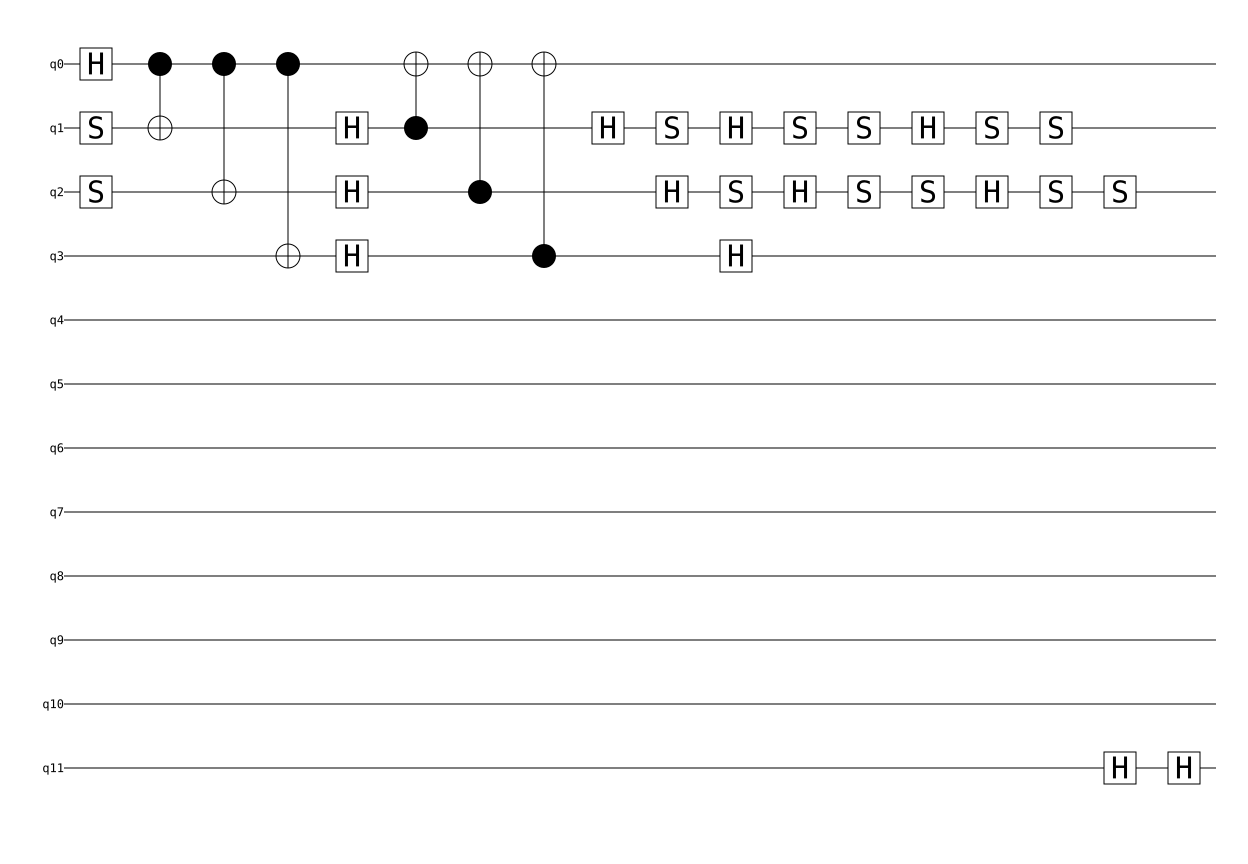

In [146]:
# Real synthesis: build ONE physical Clifford circuit implementing logical H(q)
import itertools

def _pauli_str_to_symplectic_vec(pauli: str) -> np.ndarray:
    x, z = pauli_str_to_xz(pauli)
    return np.concatenate([x, z]).astype(np.uint8)

def _symplectic_vec_to_pauli_str(v: np.ndarray) -> str:
    n2 = len(v)
    assert n2 % 2 == 0
    n = n2 // 2
    x = v[:n].astype(np.uint8)
    z = v[n:].astype(np.uint8)
    out = []
    for xi, zi in zip(x, z):
        if xi == 0 and zi == 0:
            out.append("I")
        elif xi == 1 and zi == 0:
            out.append("X")
        elif xi == 0 and zi == 1:
            out.append("Z")
        else:
            out.append("Y")
    return "".join(out)

def _gf2_inv(A: np.ndarray) -> np.ndarray:
    A = (A.copy() & 1).astype(np.uint8)
    n, m = A.shape
    if n != m:
        raise ValueError("Matrix must be square for inversion.")
    I = np.eye(n, dtype=np.uint8)
    Aug = np.hstack([A, I])

    r = 0
    for c in range(n):
        pivot = None
        for rr in range(r, n):
            if Aug[rr, c]:
                pivot = rr
                break
        if pivot is None:
            continue
        if pivot != r:
            Aug[[r, pivot]] = Aug[[pivot, r]]
        for rr in range(n):
            if rr != r and Aug[rr, c]:
                Aug[rr] ^= Aug[r]
        r += 1
        if r == n:
            break

    if not np.array_equal(Aug[:, :n], np.eye(n, dtype=np.uint8)):
        raise ValueError("Matrix is singular over GF(2).")

    return Aug[:, n:]

def _gf2_in_row_span(v: np.ndarray, basis_rows: np.ndarray) -> bool:
    v = (v.copy() & 1).astype(np.uint8).reshape(1, -1)
    if basis_rows.size == 0:
        return not np.any(v)
    M = (basis_rows.copy() & 1).astype(np.uint8)
    return gf2_rank(np.vstack([M, v])) == gf2_rank(M)

def _symp_dot(u: np.ndarray, v: np.ndarray) -> int:
    n = len(u) // 2
    ux, uz = u[:n], u[n:]
    vx, vz = v[:n], v[n:]
    return int(((ux @ vz) ^ (uz @ vx)) & 1)

def _orthogonalize_to_pairs(v: np.ndarray, pairs):
    u = (v.copy() & 1).astype(np.uint8)
    for a, b in pairs:
        if _symp_dot(u, b):
            u ^= a
        if _symp_dot(u, a):
            u ^= b
    return u

def _canonical_symplectic_basis(n: int):
    out = []
    for i in range(n):
        v = np.zeros(2*n, dtype=np.uint8); v[i] = 1      # X_i
        out.append(v)
    for i in range(n):
        v = np.zeros(2*n, dtype=np.uint8); v[n+i] = 1    # Z_i
        out.append(v)
    return out

def _extend_symplectic_pairs(initial_pairs, n: int):
    pairs = [(a.copy().astype(np.uint8), b.copy().astype(np.uint8)) for a, b in initial_pairs]
    canon = _canonical_symplectic_basis(n)

    def current_span_rows():
        if not pairs:
            return np.zeros((0, 2*n), dtype=np.uint8)
        return np.array([v for ab in pairs for v in ab], dtype=np.uint8)

    while len(pairs) < n:
        span_rows = current_span_rows()

        # Pick a new 'a' not in current span, then orthogonalize against existing pairs.
        a_new = None
        for cand in canon:
            if _gf2_in_row_span(cand, span_rows):
                continue
            a = _orthogonalize_to_pairs(cand, pairs)
            if not np.any(a):
                continue
            if _gf2_in_row_span(a, span_rows):
                continue
            a_new = a
            break
        if a_new is None:
            raise RuntimeError("Failed to find next symplectic basis vector a.")

        # Find partner b with <a,b>=1 and orthogonal to previous pairs.
        b_new = None
        for cand in canon:
            if _symp_dot(a_new, cand) == 0:
                continue
            b = _orthogonalize_to_pairs(cand, pairs)
            if _symp_dot(a_new, b) != 1:
                continue
            if _gf2_in_row_span(b, np.vstack([span_rows, a_new])):
                continue
            b_new = b
            break
        if b_new is None:
            raise RuntimeError("Failed to find partner symplectic basis vector b.")

        pairs.append((a_new, b_new))

    return pairs

def _logical_single_pauli(k: int, idx: int, p: str) -> str:
    s = ["I"] * k
    s[idx] = p
    return "".join(s)

def synthesize_physical_circuit_for_logical_H(H_in: np.ndarray, q: int, method: str = "elimination"):
    b = build_logical_bases_from_H(H_in)
    n = b["n"]
    k = b["k"]
    if not (0 <= q < k):
        raise ValueError(f"q must be in [0, {k-1}] for this code.")

    # Domain/codomain constrained pairs from logical generators.
    domain_pairs = []
    codomain_pairs = []
    expected_map = {}

    for i in range(k):
        Xin_log = _logical_single_pauli(k, i, "X")
        Zin_log = _logical_single_pauli(k, i, "Z")

        Xphys_in = logical_pauli_to_physical(H_in, Xin_log)["physical_pauli"]
        Zphys_in = logical_pauli_to_physical(H_in, Zin_log)["physical_pauli"]

        if i == q:
            Xout_log = _logical_single_pauli(k, i, "Z")
            Zout_log = _logical_single_pauli(k, i, "X")
        else:
            Xout_log = Xin_log
            Zout_log = Zin_log

        Xphys_out = logical_pauli_to_physical(H_in, Xout_log)["physical_pauli"]
        Zphys_out = logical_pauli_to_physical(H_in, Zout_log)["physical_pauli"]

        domain_pairs.append((_pauli_str_to_symplectic_vec(Xphys_in), _pauli_str_to_symplectic_vec(Zphys_in)))
        codomain_pairs.append((_pauli_str_to_symplectic_vec(Xphys_out), _pauli_str_to_symplectic_vec(Zphys_out)))

        expected_map[f"X{i}"] = Xphys_out
        expected_map[f"Z{i}"] = Zphys_out

    # Complete both to full symplectic bases.
    D_pairs = _extend_symplectic_pairs(domain_pairs, n)
    C_pairs = _extend_symplectic_pairs(codomain_pairs, n)

    # Build map F (column convention): v_out = F @ v_in over GF(2).
    D_cols = [a for a, _ in D_pairs] + [b for _, b in D_pairs]
    C_cols = [a for a, _ in C_pairs] + [b for _, b in C_pairs]
    D = np.stack(D_cols, axis=1).astype(np.uint8)
    C = np.stack(C_cols, axis=1).astype(np.uint8)
    F = (C @ _gf2_inv(D)) % 2

    # Convert map of physical generators into a Stim tableau and synthesize a circuit.
    xs = []
    zs = []
    for j in range(n):
        v = F[:, j]
        xs.append(stim.PauliString(_symplectic_vec_to_pauli_str(v)))
    for j in range(n):
        v = F[:, n + j]
        zs.append(stim.PauliString(_symplectic_vec_to_pauli_str(v)))

    tableau = stim.Tableau.from_conjugated_generators(xs=xs, zs=zs)
    circuit = tableau.to_circuit(method=method)

    # Verify desired logical generator action (phase ignored).
    checks = {}
    for i in range(k):
        for p in ("X", "Z"):
            key = f"{p}{i}"
            in_log = _logical_single_pauli(k, i, p)
            in_phys = logical_pauli_to_physical(H_in, in_log)["physical_pauli"]
            vin = _pauli_str_to_symplectic_vec(in_phys)
            vout = (F @ vin) % 2
            got = _symplectic_vec_to_pauli_str(vout)
            exp = expected_map[key]
            checks[key] = {"ok": got == exp, "got": got, "expected": exp}

    return {
        "n": n,
        "k": k,
        "q": q,
        "F": F,
        "tableau": tableau,
        "circuit": circuit,
        "checks": checks,
    }

# Example: synthesize ONE physical circuit for logical H on qubit q=4
synth = synthesize_physical_circuit_for_logical_H(H, q=0, method="elimination")
all_ok = all(v["ok"] for v in synth["checks"].values())
print(f"Synthesized physical Clifford circuit for logical H on q={synth['q']}.")
print(f"n={synth['n']}, k={synth['k']}, generator-map checks passed: {all_ok}")
print(f"Circuit operation count: {len(synth['circuit'])}")

for gen, info in synth["checks"].items():
    tag = "OK" if info["ok"] else "MISMATCH"
    print(f"  {tag}  {gen}: {info['expected']}  <=  {info['got']}")

# One actual synthesized circuit (not split into X/Z image mini-circuits)
svg_text = str(synth["circuit"].diagram("timeline-svg"))
svg_path = f"logical_H_q{synth['q']}_timeline.svg"
with open(svg_path, "w", encoding="utf-8") as f:
    f.write(svg_text)

print(f"Saved diagram to: {svg_path}")
synth["circuit"].diagram("timeline-svg")

Generator-map checks passed: True
Total ops in full circuit: 56
syndromes_full shape: (5000, 5)
final_data_full shape: (5000, 12)
first 5 syndrome rows:
 [[1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]]
first 5 final data rows:
 [[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


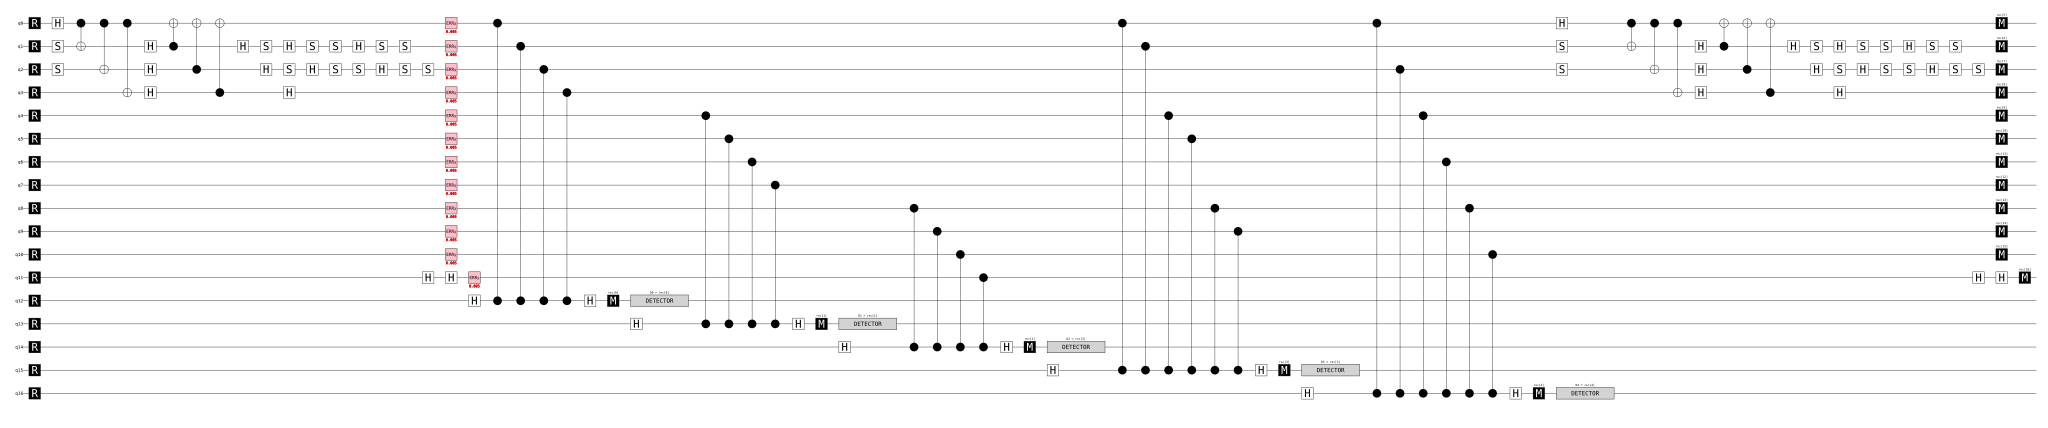

In [ ]:
# def build_full_h_ec_h_measure_circuit(
#     H_in: np.ndarray,
#     logical_q: int = 0,
#     p_data: float = 0.005,
#     p_meas: float = 0.0,
#     method: str = "elimination",
# ):
#     """
#     Build a full circuit:
#       1) Reset data+ancilla
#       2) Apply synthesized logical H on logical_q
#       3) One noisy EC/syndrome-extraction round
#       4) Apply synthesized logical H again
#       5) Final data measurement
#     """
#     H_in = (H_in & 1).astype(np.uint8)
#     m, n = H_in.shape
#     data = list(range(n))
#     anc = list(range(n, n + m))

#     # Synthesized physical Clifford for logical H on chosen logical qubit
#     h_synth = synthesize_physical_circuit_for_logical_H(H_in, q=logical_q, method=method)

#     c = stim.Circuit()
#     c.append("R", data + anc)

#     # Initial logical H
#     c += h_synth["circuit"]

#     # Data noise before EC round
#     if p_data > 0:
#         c.append("X_ERROR", data, float(p_data))

#     # One syndrome extraction round (Z checks from H)
#     for i in range(m):
#         a = anc[i]
#         support = [j for j, bit in enumerate(H_in[i]) if bit]
#         c.append("H", [a])
#         for q in support:
#             c.append("CZ", [a, q])
#         c.append("H", [a])
#         if p_meas > 0:
#             c.append("X_ERROR", [a], float(p_meas))
#         c.append("M", [a])
#         c.append("DETECTOR", [stim.target_rec(-1)])

#     # Logical H again
#     c += h_synth["circuit"]

#     # Final data measurement
#     c.append("M", data)

#     return c, h_synth


# def sample_full_h_ec_h_measure(circuit: stim.Circuit, H_in: np.ndarray, shots: int = 1000):
#     """
#     Measurement order here is [all ancilla syndrome bits, then all final data bits].
#     """
#     m, n = H_in.shape
#     meas = circuit.compile_sampler().sample(shots=shots).astype(np.uint8)
#     syndromes = meas[:, :m]
#     final_data = meas[:, m:m + n]
#     return syndromes, final_data


# # Example usage on existing H
# full_circuit, full_h_info = build_full_h_ec_h_measure_circuit(
#     H, logical_q=0, p_data=0.005, p_meas=0.0
# )

# print("Generator-map checks passed:", all(v["ok"] for v in full_h_info["checks"].values()))
# print("Total ops in full circuit:", len(full_circuit))

# syndromes_full, final_data_full = sample_full_h_ec_h_measure(full_circuit, H, shots=5000)
# print("syndromes_full shape:", syndromes_full.shape)
# print("final_data_full shape:", final_data_full.shape)
# print("first 5 syndrome rows:\n", syndromes_full[:5])
# print("first 5 final data rows:\n", final_data_full[:5])

# # Optional visualization
# full_circuit.diagram("timeline-svg")